In [1]:
import nltk
import pandas as pd
import requests
import string
from collections import Counter, defaultdict
import random
from PyPDF2 import PdfReader
import io
import matplotlib.pyplot as plt

In [2]:
# use api to read in bill data
# add environment variable in future to store hashed key in
# max return is 250 but we can add an offset so we can iterate through a certain timeframe to create our dataset

#url = f'https://api.congress.gov/v3/bill?api_key={KEY}'

# things to test
# stemmed vs unstemmed clean vs unclean
# different size word vectors


In [3]:
def load_summaries(key, n=10):
  """
  Take in the number of bills to process (n, int) and output
  a list of summaries and a list of decisions

  THIS NEEDS FIXING NEXT
  """

  # get bills
  #params = {'limit':n}
  params = {'fromDateTime': '2020-01-01T00:00:00Z',
            'toDateTime': '2025-07-30T00:00:00Z',
            'limit':250}
  """
  url_bills = f'https://api.congress.gov/v3/bill?api_key={key}'
  r_bills = requests.get(url_bills, params=params)

  # get bill number and congress number
  numbers = []
  congresses = []
  for bill in r_bills.json()['bills']:
    congresses.append(bill['congress'])
    numbers.append(bill['number'])

  # iterate through bills and get their summaries and max decisions
  """
  sums = []
  decisions = []
  for i in range(len(congresses)):
    url_summaries = f'https://api.congress.gov/v3/bill/{congresses[i]}/hr/{numbers[i]}/summaries?api_key={key}'
    r = requests.get(url_summaries, params=params)
    summaries = r.json()['summaries']
    print(summaries)
    if len(summaries) > 0:
      sums.append([bill['text'] for bill in summaries][-1])
      decisions.append([bill['actionDesc'] for bill in summaries][-1])

  return sums, decisions

def load_decisions(df, outcomes):
    """
    Take in data from dataframe that has con, num, hr_s rows that describe the details of the bill and extract
    pdfs by constrocting URL from this information
    """
    # source for pdf reader code https://stackoverflow.com/questions/64986673/extracting-text-from-pdf-url-file-with-python
    texts = []
    tracker = []
    i = 0
    for index, row in df.iterrows():
        for track in outcomes:
            try:
                # read through pdfs
                pdf = f"https://www.congress.gov/{row['con']}/bills/{row['hr_s']}{row['num']}/BILLS-{row['con']}{row['hr_s']}{row['num']}{track}.pdf"
                r = requests.get(pdf)
                iobytes = io.BytesIO(r.content)
                reader = PdfReader(iobytes)
                text = " ".join([page.extract_text() for page in reader.pages])
                texts.append(text)
                tracker.append(row['Latest Tracker Stage'])
                
                break
                
            except:
                continue
        i +=1
        # update every 200 too keep track of progress
        if i % 200 == 199:
            print(i)
    
    return texts, tracker

In [4]:
def stop(txt):
  """
  take in .txt file with words separated by lines and create a list
  of stop words
  """
  with open(txt, 'r') as f:
    stop_words = f.readlines()
  return [word.strip() for word in stop_words]

def clean_txt(texts):
  """
  take in list of strings of text (texts) and remove punctuation, linesplits,
  and stop words (list input)
  """
  clean = []
  # iterate through texts
  for text in texts:

    # remove html type text and other numbers
    for h in ["<p>", "<strong>", "</p>", "<ul>", "</ul>", "</strong>",'0','—', '1','2','3','4','5','6','7','8','9', "'", '"', '.','‘',"’","æ"]:
      text = text.replace(h, ' ')

    # lower text
    text = text.lower()

    # remove punctuation
    for p in string.punctuation:
      text = text.replace(p, '')

    # remove extra whitespace
    words = text.split()
    for word in words:
      for w in string.whitespace:
        word = word.replace(w, '')

    # rejoin cleaned text
    text = ' '.join(words)
    clean.append(text)


  return clean



def stem(texts):
  """
  Take in list of texts (list (str)) and stem words within texts
  return list of stemmed texts
  """

  ps = nltk.PorterStemmer()
  stemmed = []
  # iterate through all words and stem them using porterstemm from NLTK
  for text in texts:
    for word in text.split():
      text = text.replace(word, ps.stem(word))
    stemmed.append(text)
  return stemmed


In [5]:
def word_bank(texts, stop,  n=75):
  """
  takes in list of texts (list (str)) and finds which words are used the most
  outside of stop words (list (str))
  and returns a list of the top n (int) words
  """
  words = " ".join(texts).split()
  words = [word for word in " ".join(texts).split() if word not in stop]
  counts = Counter(words)
  sort = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:n]
  return [word[0] for word in sort]

In [6]:
# set up bayesian model with prior, conditional and posterior and iterations
def p_word_given_result(train_data_texts, train_data_outcomes, word_vector):
  """
  Take in training data texts (list (string)) and the outcomes for those texts
  find the likelihood of each word in the word vector given the outcome
  return a dictioary of the conditional likelihoods p(wi|oi)
  (probability of word i given outcome i)
  """
  prob = defaultdict(int)

  # iterate through all words in vector
  for word in word_vector:
    unique_outcomes = []
    total_appearances = 0
    # iterate through train data and check to see if the word is in the text
    for i in range(len(train_data_texts)):
      if word in train_data_texts[i].split():
        prob[word + f"{train_data_outcomes[i]}"] += 1
        unique_outcomes.append(train_data_outcomes[i])
        total_appearances +=1

    # normalize the probabilities for that word
    for outcome in set(unique_outcomes):
      prob[word + f"{outcome}"]  = prob[word + f"{outcome}"] / total_appearances

  return prob

def posterior(prior, conditional, text, trackers, word_vector):
    """
    Take in prior distribution, conditional distribution and text to find the posterior distribution for a text
    """
    max_outcome = 0
    joint = {}
    # for each outcome
    for track in trackers:
        post_prob = 1

        # find probability of specific document
        for word in word_vector:

            appearance = 0 if word not in text.split() else 1

            # avoid division by zero by always making prob non-negative
            curr_prob = (appearance * conditional[word + track] + (1-appearance)*(1 - conditional[word + track])) 
            curr_prob = 0.000001 if curr_prob == 0 else curr_prob
            curr_prob = .9999999 if curr_prob == 1 else curr_prob
            post_prob = post_prob * curr_prob


        # update the prior
        joint[track] = post_prob

    # marginalize the maximum over the sum of probabilities
    marginal = sum([joint[track] * prior[track] for track in trackers])
    posterior = {track: joint[track] * prior[track] / marginal for track in trackers}

    # prediction is max of posterior
    prediction = max(posterior, key=posterior.get)

    return posterior, prediction

def predict(summary_train, decision_train,summaries_test, stopwords, num_words, prior):
    """ Takes in a list of training texts and decisions, a list of stop words,
    and the number of words to make predictions based on
    uses posterior to predict the likelihood of each decision and maximizes
    bases this of of test summaries (list of texts)
    """
    # find word vector
    word_vectors = word_bank(summary_train, stopwords, num_words)
    
    # find conditional probabilities based on training data
    prob = p_word_given_result(summary_train, decision_train , word_vectors)

    # find the posterior decisions
    trackers = list(set(decisions_train))

    preds = []

    # calculate posteriors and take predictions that has highest posterior likelihood value
    for i in range(len(summaries_test)):
        # for stemmed 
        post = posterior(prior, prob, summaries_test[i], trackers, word_vectors)[0]
        pred = max(post, key=post.get)
        preds.append(pred)

    return preds
        
    
    

In [7]:
#load summaries and decisions
#n = 5
#summaries, decisions = load_summaries(n=n, key=userdata.get('KEY'))
df = pd.read_csv('bills.csv', delimiter=',')
# use this to make sure it works
df = df.sample(4000)
outcomes = ['enr',"ih",'pcs', 'fps', 'is', 'rfs', 'eas', 'es']
df['hr_s'] = df['Legislation Number'].apply(lambda x: 's' if 'S' in x.split() else 'hr')
df['num'] = df['Legislation Number'].apply(lambda x: ''.join([char for char in x if char.isdigit()]))
df['con'] = df['Congress'].apply(lambda x: ''.join([char for char in x[:5] if char.isdigit()]))
summaries, decisions = load_decisions(df, outcomes)


199
399
599
799
999
1199
1399
1599
1799
1999
2199
2399
2599
2799
2999
3199
3399
3599
3799
3999


In [8]:
# clean summaries
stopwords = stop('stopwords.txt')
summaries_clean = clean_txt(summaries)
summaries_stemmed = stem(summaries_clean)

In [10]:
# split into training and test data
n = len(summaries_clean)
train_idx = random.sample(range(n), int(n * .8))
# unstemmed
summaries_train_us = [summaries_clean[i] for i in train_idx]
summaries_test_us = [summaries_clean[i] for i in range(n) if i not in train_idx]

# stemmed
summaries_train_s = [summaries_stemmed[i] for i in train_idx]
summaries_test_s = [summaries_stemmed[i] for i in range(n) if i not in train_idx]

# train/test data outcomes
decisions_train = [decisions[i] for i in train_idx]
decisions_test = [decisions[i] for i in range(n) if i not in train_idx]

# split test into 50/50 test/val
n = len(decisions_test)
idx = random.sample(range(n), int(n * .5))

# unstemmed
summaries_val_us = [summaries_test_us[i] for i in idx]
summaries_test_us = [summaries_test_us[i] for i in range(n) if i not in idx]

# stemmed
summaries_val_s = [summaries_test_s[i] for i in idx]
summaries_test_s = [summaries_test_s[i] for i in range(n) if i not in idx]

# train/test data outcomes
decisions_val = [decisions_test[i] for i in idx]
decisions_test = [decisions_test[i] for i in range(n) if i not in idx]


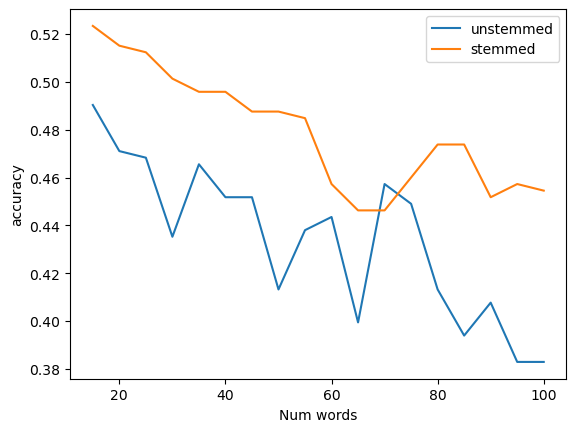

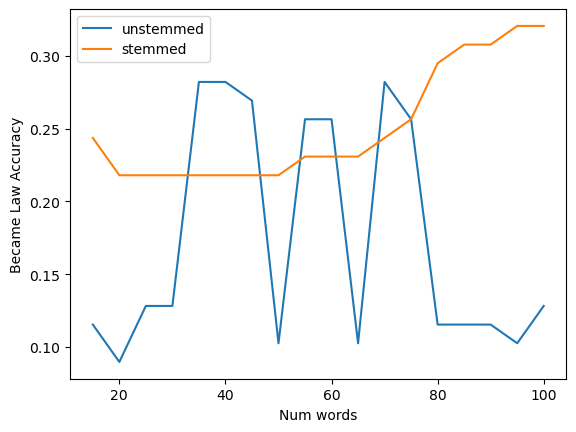

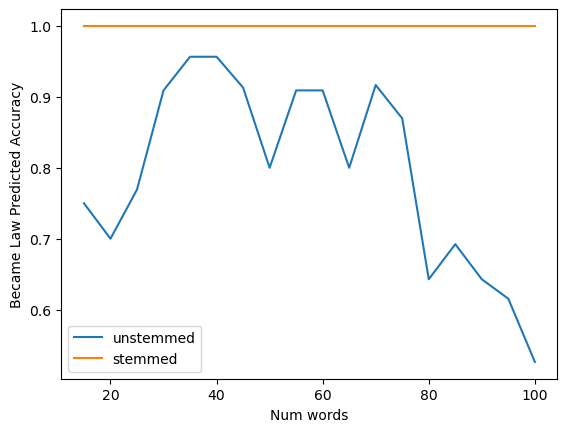

In [12]:
# generate an array of word vectors to test
accuracies_s = []
became_law_acc_s = []
became_law_acc_us = []
became_law_pred_acc_s = []
became_law_pred_acc_us = []
accuracies_us = []
num_words = []
trackers = list(set(decisions_train))

# test and plot based on prior 1 (even prior)
prior1 = {track: 1/len(trackers) for track in trackers}

for v in range(15,101, 5):

    # find predictions
    predus = predict(summaries_train_us, decisions_train, summaries_val_us, stopwords, v, prior1)
    preds = predict(summaries_train_s, decisions_train, summaries_val_s, stopwords, v, prior1)

    # find total accuracies
    accuracies_us.append(sum([1 for i in range(len(predus)) if predus[i]== decisions_val[i]])/len(predus))
    accuracies_s.append(sum([1 for i in range(len(preds)) if preds[i]== decisions_val[i]])/len(preds))
    num_words.append(v)

    # find became law accuracies unstemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=predus)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_us.append(bl_acc)
    became_law_pred_acc_us.append(pbl_acc)
    

    # find became law accuracies stemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=preds)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_s.append(bl_acc)
    became_law_pred_acc_s.append(pbl_acc)

# plot outputs
plt.plot(num_words, accuracies_us, label='unstemmed')
plt.plot(num_words, accuracies_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('accuracy')
plt.show()
plt.plot(num_words, became_law_acc_us, label='unstemmed')
plt.plot(num_words, became_law_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Accuracy')
plt.show()
plt.plot(num_words, became_law_pred_acc_us, label='unstemmed')
plt.plot(num_words, became_law_pred_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Predicted Accuracy')
plt.show()

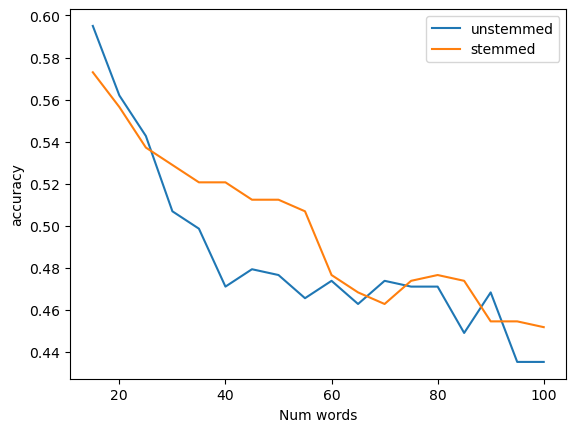

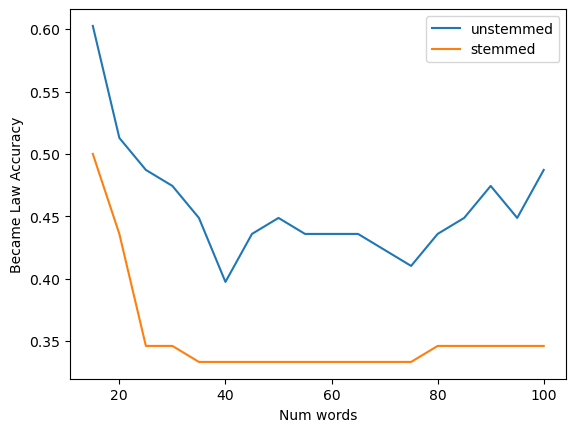

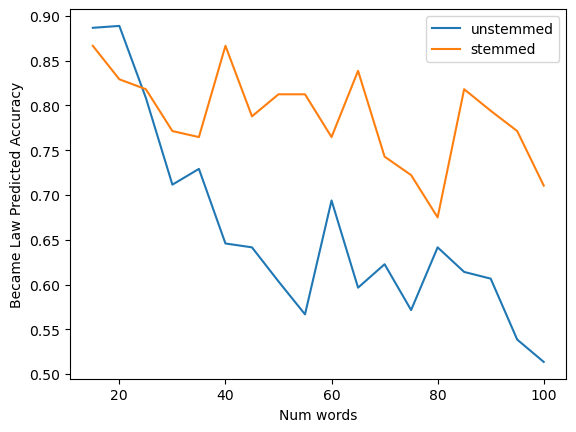

In [17]:
# test prior 2
prior2 = {"Became Law": .98, "Failed House": .002, "Introduced": .007, "Passed House": .007, "Passed Senate": .002, "Vetoed by President": .001,
          "Failed Senate": .0005, "Became Private Law": 0.00025, "Resolving Differences": .00025}
# generate an array of word vectors to test
accuracies_s = []
became_law_acc_s = []
became_law_acc_us = []
became_law_pred_acc_s = []
became_law_pred_acc_us = []
accuracies_us = []
num_words = []

for v in range(15,101, 5):

    # find predictions
    predus = predict(summaries_train_us, decisions_train, summaries_val_us, stopwords, v, prior2)
    preds = predict(summaries_train_s, decisions_train, summaries_val_s, stopwords, v, prior2)

    # find total accuracies
    accuracies_us.append(sum([1 for i in range(len(predus)) if predus[i]== decisions_val[i]])/len(predus))
    accuracies_s.append(sum([1 for i in range(len(preds)) if preds[i]== decisions_val[i]])/len(preds))
    num_words.append(v)

    # find became law accuracies unstemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=predus)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_us.append(bl_acc)
    became_law_pred_acc_us.append(pbl_acc)
    

    # find became law accuracies stemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=preds)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_s.append(bl_acc)
    became_law_pred_acc_s.append(pbl_acc)

# plot outputs
plt.plot(num_words, accuracies_us, label='unstemmed')
plt.plot(num_words, accuracies_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('accuracy')
plt.show()
plt.plot(num_words, became_law_acc_us, label='unstemmed')
plt.plot(num_words, became_law_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Accuracy')
plt.show()
plt.plot(num_words, became_law_pred_acc_us, label='unstemmed')
plt.plot(num_words, became_law_pred_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Predicted Accuracy')
plt.show()

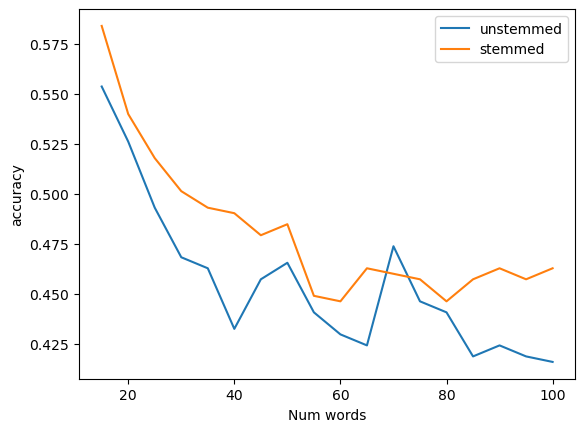

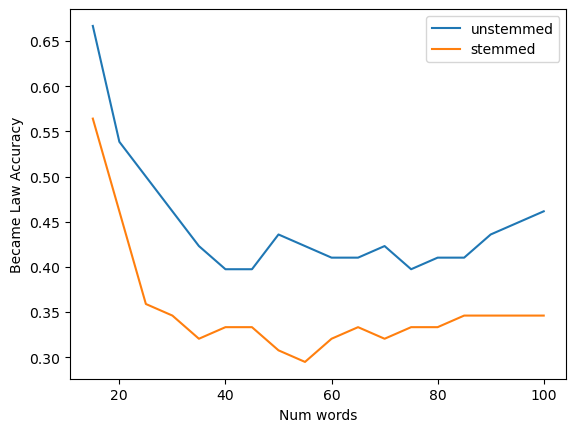

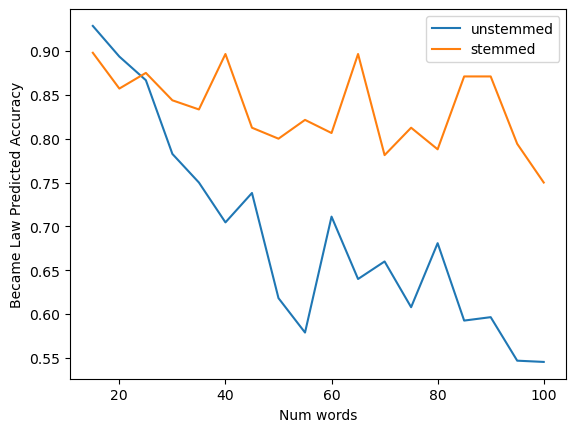

In [18]:
# test prior 3
prior3 = {"Became Law": .98, "Failed House": .002, "Introduced": .002, "Passed House": .012, "Passed Senate": .002, "Vetoed by President": .001,
         "Failed Senate": .0005, "Became Private Law": 0.00025, "Resolving Differences": .00025}

# generate an array of word vectors to test
accuracies_s = []
became_law_acc_s = []
became_law_acc_us = []
became_law_pred_acc_s = []
became_law_pred_acc_us = []
accuracies_us = []
num_words = []

for v in range(15,101, 5):

    # find predictions
    predus = predict(summaries_train_us, decisions_train, summaries_val_us, stopwords, v, prior3)
    preds = predict(summaries_train_s, decisions_train, summaries_val_s, stopwords, v, prior3)

    # find total accuracies
    accuracies_us.append(sum([1 for i in range(len(predus)) if predus[i]== decisions_val[i]])/len(predus))
    accuracies_s.append(sum([1 for i in range(len(preds)) if preds[i]== decisions_val[i]])/len(preds))
    num_words.append(v)

    # find became law accuracies unstemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=predus)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_us.append(bl_acc)
    became_law_pred_acc_us.append(pbl_acc)
    

    # find became law accuracies stemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=preds)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_s.append(bl_acc)
    became_law_pred_acc_s.append(pbl_acc)

# plot outputs
plt.plot(num_words, accuracies_us, label='unstemmed')
plt.plot(num_words, accuracies_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('accuracy')
plt.show()
plt.plot(num_words, became_law_acc_us, label='unstemmed')
plt.plot(num_words, became_law_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Accuracy')
plt.show()
plt.plot(num_words, became_law_pred_acc_us, label='unstemmed')
plt.plot(num_words, became_law_pred_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Predicted Accuracy')
plt.show()

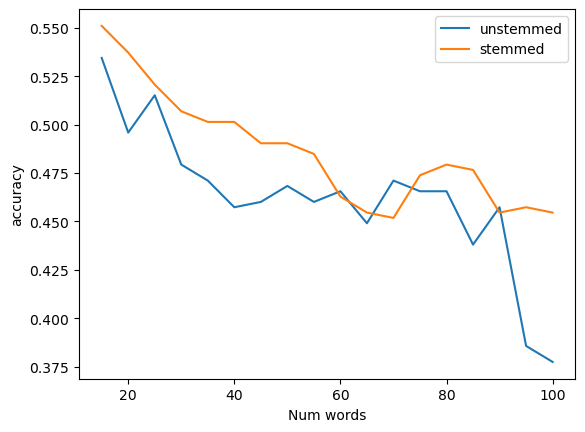

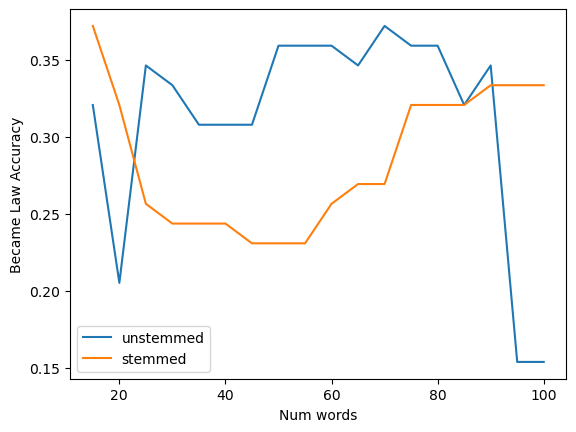

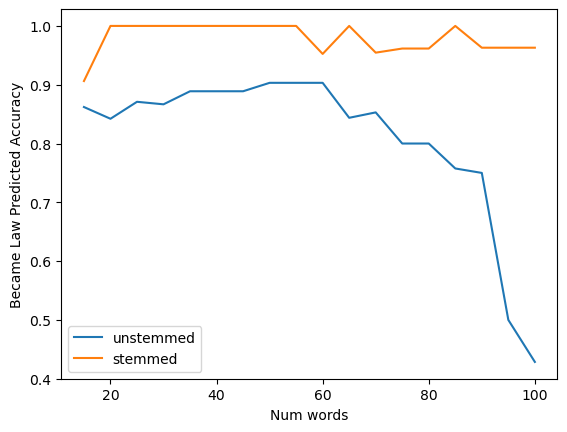

In [19]:
prior4 = {"Became Law": .5, "Failed House": .1, "Introduced": .1, "Passed House": .1, "Passed Senate": .1, "Vetoed by President": .099,
         "Failed Senate": .0005, "Became Private Law": 0.00025, "Resolving Differences": .00025}

# generate an array of word vectors to test
accuracies_s = []
became_law_acc_s = []
became_law_acc_us = []
became_law_pred_acc_s = []
became_law_pred_acc_us = []
accuracies_us = []
num_words = []

for v in range(15,101, 5):

    # find predictions
    predus = predict(summaries_train_us, decisions_train, summaries_val_us, stopwords, v, prior4)
    preds = predict(summaries_train_s, decisions_train, summaries_val_s, stopwords, v, prior4)

    # find total accuracies
    accuracies_us.append(sum([1 for i in range(len(predus)) if predus[i]== decisions_val[i]])/len(predus))
    accuracies_s.append(sum([1 for i in range(len(preds)) if preds[i]== decisions_val[i]])/len(preds))
    num_words.append(v)

    # find became law accuracies unstemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=predus)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_us.append(bl_acc)
    became_law_pred_acc_us.append(pbl_acc)
    

    # find became law accuracies stemmed
    pred_v_acc = pd.crosstab(index=decisions_val, columns=preds)
    try:
        pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
        bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
    except:
        pbl_acc, bl_acc = 0, 0
    became_law_acc_s.append(bl_acc)
    became_law_pred_acc_s.append(pbl_acc)

# plot outputs
plt.plot(num_words, accuracies_us, label='unstemmed')
plt.plot(num_words, accuracies_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('accuracy')
plt.show()
plt.plot(num_words, became_law_acc_us, label='unstemmed')
plt.plot(num_words, became_law_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Accuracy')
plt.show()
plt.plot(num_words, became_law_pred_acc_us, label='unstemmed')
plt.plot(num_words, became_law_pred_acc_s, label = 'stemmed')
plt.legend()
plt.xlabel('Num words')
plt.ylabel('Became Law Predicted Accuracy')
plt.show()

In [25]:
# test on the "best scenario", stemmed, 20 words, prior set 4
# find prediction
n = 20
preds = predict(summaries_train_s, decisions_train, summaries_test_s, stopwords, n, prior4)

# find total accuracies
acc = sum([1 for i in range(len(preds)) if preds[i]== decisions_test[i]])/len(preds)

# find became law accuracies stemmed
pred_v_acc = pd.crosstab(index=decisions_test, columns=preds)
try:
    pbl_acc = pred_v_acc["Became Law"].loc["Became Law"] / sum(pred_v_acc["Became Law"])
    bl_acc = pred_v_acc.loc["Became Law"].loc["Became Law"] / sum(pred_v_acc.loc["Became Law"])
except:
    pbl_acc, bl_acc = 0, 0

In [26]:
print(acc, pbl_acc, bl_acc)

0.5785123966942148 0.9655172413793104 0.4444444444444444


In [ ]:
# we want to capture med vs unstemmed
# we want to use the three above priors
# we want to use many total words
# we want to plot total accuracy
# we want to 

In [ ]:
# changes we made so far
# uneven prior
# do not update the prior based on prev posterior
# number of words
# we are using stemmed rather than unstemmed